# Gathering data and preprocessing
## Dependencies and dataset imports

In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import datetime
from pandas.tseries.holiday import USFederalHolidayCalendar as calendar

In [2]:
import pandas as pd
import pyarrow.dataset as ds

pd.set_option('display.max_columns', None)

# 1. Open the file as a dataset object
dataset = ds.dataset("./Dataset/Flight_Delay.parquet", format="parquet")

# 2. Convert it directly to a pandas DataFrame
df = dataset.to_table().to_pandas()

# 3. Clean up the index
df.reset_index(drop=True, inplace=True)
print(df.head())

   Year  Month  DayofMonth  FlightDate Marketing_Airline_Network  \
0  2018      1          15  2018-01-15                        UA   
1  2018      1          16  2018-01-16                        UA   
2  2018      1          17  2018-01-17                        UA   
3  2018      1          18  2018-01-18                        UA   
4  2018      1          20  2018-01-20                        UA   

  OriginCityName    DestCityName  CRSDepTime  DepTime  DepDelay  \
0     Newark, NJ  Charleston, SC        1845   1928.0      43.0   
1     Newark, NJ  Charleston, SC        1835   1956.0      81.0   
2     Newark, NJ  Charleston, SC        1835   1836.0       1.0   
3     Newark, NJ  Charleston, SC        1845   1844.0      -1.0   
4     Newark, NJ  Charleston, SC        1835   1829.0      -6.0   

   DepDelayMinutes  TaxiOut  WheelsOff  WheelsOn  TaxiIn  CRSArrTime  ArrTime  \
0             43.0     35.0     2003.0    2145.0     4.0        2108   2149.0   
1             81.0     18.

## Understanding given data

In [3]:
def describe_columns(givenDataFrame: pd.DataFrame) -> pd.DataFrame:
    summary = []
    for col in givenDataFrame.columns:
        dtype = givenDataFrame[col].dtype
        unique_count = givenDataFrame[col].nunique(dropna=False)
        missing_count = givenDataFrame[col].isna().sum()
        top_values = givenDataFrame[col].value_counts(dropna=False).nlargest(3)

        summary.append({
            "column": col,
            "dtype": dtype,
            "unique_values": unique_count,
        })

    return pd.DataFrame(summary)

summary_df = describe_columns(df)
summary_df

,column,dtype,unique_values
0,Year,int64,6
1,Month,int64,12
2,DayofMonth,int64,31
3,FlightDate,object,1946
4,Marketing_Airline_Network,object,11
5,OriginCityName,object,382
6,DestCityName,object,382
7,CRSDepTime,int64,1426
8,DepTime,float64,1440
9,DepDelay,float64,2100


In [4]:
df.shape

(30132672, 29)

In [5]:
df['FlightDate']

0           2018-01-15
1           2018-01-16
2           2018-01-17
3           2018-01-18
4           2018-01-20
               ...    
30132667    2023-04-26
30132668    2023-04-26
30132669    2023-04-26
30132670    2023-04-26
30132671    2023-04-26
Name: FlightDate, Length: 30132672, dtype: object

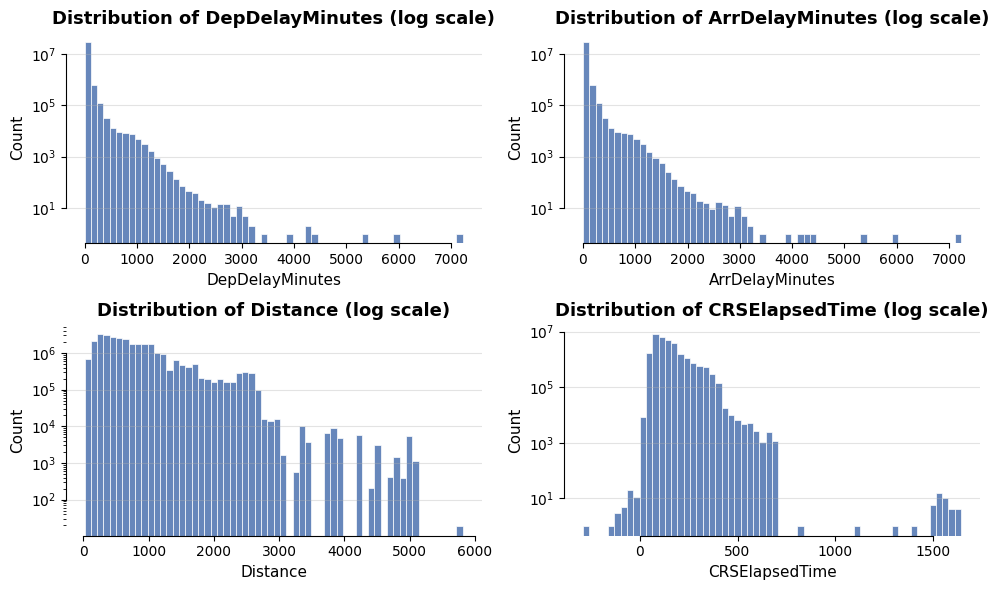

In [6]:
def plot_histogram_grid(
    givenDataFrame: pd.DataFrame,
    columns: list[str],
    ncols: int = 3,
    bins: int = 50,
    log_scale: bool = False,
    figsize: tuple[int, int] = (10, 6)
) -> None:
    ncols = max(1, ncols)
    nrows = (len(columns) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, columns):
        sns.histplot(
            givenDataFrame[col].dropna(),
            bins=bins,
            kde=False,
            color="#4C72B0",
            edgecolor="white",
            linewidth=0.5,
            alpha=0.85,
            ax=ax
        )
        ax.set_title(f"Distribution of {col}", fontsize=13, weight="bold")
        ax.set_xlabel(col, fontsize=11)
        ax.set_ylabel("Count", fontsize=11)
        if log_scale:
            ax.set_yscale("log")
            ax.set_title(f"Distribution of {col} (log scale)", fontsize=13, weight="bold")
        ax.grid(axis="y", alpha=0.35)
    
    for empty_ax in axes[len(columns):]:
        empty_ax.axis("off")

    sns.despine(trim=True)
    plt.tight_layout()
    plt.show()

plot_histogram_grid(
    df,
    columns=["DepDelayMinutes", "ArrDelayMinutes", "Distance", "CRSElapsedTime"],
    ncols=2,
    bins=60,
    log_scale=True,
    figsize=(10, 6)
)

Histograms suggest that data includes some extreme outliers (e.g., delays up to 7000 minutes ≈ multiple days), which is a perfect case study for imbalanced regression task.

Also, data anomalies detected (scheduled flight time with negative values)

In [7]:
df['Marketing_Airline_Network'].unique()

array(['UA', 'DL', 'F9', 'NK', 'AA', 'WN', 'AS', 'HA', 'VX', 'B6', 'G4'],
      dtype=object)

In [8]:
df['OriginCityName']

0              Newark, NJ
1              Newark, NJ
2              Newark, NJ
3              Newark, NJ
4              Newark, NJ
                ...      
30132667      Houston, TX
30132668      Chicago, IL
30132669    Las Vegas, NV
30132670        Miami, FL
30132671        Tampa, FL
Name: OriginCityName, Length: 30132672, dtype: object

OriginCityName contains information about both city and state, for the purposes of this analysis it's better to keep them separated.

### Memory usage

In [9]:
print(f"{df.memory_usage(deep=True).sum() / 1e9:.2f} GB")  # in GB

13.08 GB


In [10]:
df.memory_usage(deep=True).sort_values(ascending=False) / 1e6  # MB per column

OriginCityName               1871.873860
DestCityName                 1871.674413
FlightDate                   1777.827648
Marketing_Airline_Network    1536.766272
DayofMonth                    241.061376
Year                          241.061376
DepDelay                      241.061376
Month                         241.061376
CRSDepTime                    241.061376
DepTime                       241.061376
TaxiOut                       241.061376
DepDelayMinutes               241.061376
WheelsOff                     241.061376
WheelsOn                      241.061376
AirTime                       241.061376
TaxiIn                        241.061376
CRSArrTime                    241.061376
ArrTime                       241.061376
ArrDelay                      241.061376
ArrDelayMinutes               241.061376
CRSElapsedTime                241.061376
ActualElapsedTime             241.061376
WeatherDelay                  241.061376
Distance                      241.061376
DistanceGroup   

### Checking for missing data

In [11]:
def printMissingDataSummary(givenDataFrame: pd.DataFrame) -> None:
    missingCount = givenDataFrame.isna().sum()
    missingPercentage = (missingCount / len(givenDataFrame) * 100).round(2)

    missingSummary = pd.DataFrame({
        "missingCount": missingCount,
        "missingPercentage": missingPercentage
    })

    print("\nMissing data summary:")
    print(missingSummary)

printMissingDataSummary(df)


Missing data summary:
                           missingCount  missingPercentage
Year                                  0                0.0
Month                                 0                0.0
DayofMonth                            0                0.0
FlightDate                            0                0.0
Marketing_Airline_Network             0                0.0
OriginCityName                        0                0.0
DestCityName                          0                0.0
CRSDepTime                            0                0.0
DepTime                               0                0.0
DepDelay                              0                0.0
DepDelayMinutes                       0                0.0
TaxiOut                               0                0.0
WheelsOff                             0                0.0
WheelsOn                              0                0.0
TaxiIn                                0                0.0
CRSArrTime                       

In [12]:
df.describe()

,Year,Month,DayofMonth,CRSDepTime,DepTime,DepDelay,DepDelayMinutes,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrTime,ArrDelay,ArrDelayMinutes,CRSElapsedTime,ActualElapsedTime,AirTime,Distance,DistanceGroup,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
count,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07
mean,2.020091e+03,6.297564e+00,1.572297e+01,1.322736e+03,1.327245e+03,1.061144e+01,1.429690e+01,1.650212e+01,1.350119e+03,1.456780e+03,7.453306e+00,1.485342e+03,1.462064e+03,3.754417e+00,1.443629e+01,1.388678e+02,1.320092e+02,1.080538e+02,7.764743e+02,3.580303e+00,5.050473e+00,8.417200e-01,2.994112e+00,2.741088e-02,5.522570e+00
std,1.602171e+00,3.487835e+00,8.770224e+00,4.840125e+02,4.983890e+02,5.198293e+01,5.081470e+01,9.467169e+00,4.998794e+02,5.249568e+02,6.024017e+00,5.081119e+02,5.286442e+02,5.454628e+01,5.072644e+01,7.096150e+01,7.061227e+01,6.872621e+01,5.823315e+02,2.291205e+00,3.370024e+01,1.509353e+01,1.664252e+01,1.650743e+00,2.751737e+01
min,2.018000e+03,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-3.420000e+02,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,-1.290000e+03,0.000000e+00,-2.920000e+02,4.000000e+00,-1.412000e+03,1.600000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.019000e+03,3.000000e+00,8.000000e+00,9.150000e+02,9.160000e+02,-6.000000e+00,0.000000e+00,1.100000e+01,9.310000e+02,1.046000e+03,4.000000e+00,1.105000e+03,1.050000e+03,-1.700000e+01,0.000000e+00,8.800000e+01,8.100000e+01,5.800000e+01,3.520000e+02,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.020000e+03,6.000000e+00,1.600000e+01,1.315000e+03,1.320000e+03,-3.000000e+00,0.000000e+00,1.400000e+01,1.333000e+03,1.456000e+03,6.000000e+00,1.510000e+03,1.500000e+03,-9.000000e+00,0.000000e+00,1.200000e+02,1.140000e+02,9.000000e+01,6.200000e+02,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2.022000e+03,9.000000e+00,2.300000e+01,1.729000e+03,1.737000e+03,3.000000e+00,3.000000e+00,1.900000e+01,1.751000e+03,1.903000e+03,9.000000e+00,1.914000e+03,1.909000e+03,-1.000000e+00,0.000000e+00,1.690000e+02,1.620000e+02,1.370000e+02,1.011000e+03,5.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,2.023000e+03,1.200000e+01,3.100000e+01,2.359000e+03,2.400000e+03,7.223000e+03,7.223000e+03,1.439000e+03,2.400000e+03,2.400000e+03,1.082000e+03,2.400000e+03,2.400000e+03,7.232000e+03,7.232000e+03,1.645000e+03,1.604000e+03,1.557000e+03,5.812000e+03,1.100000e+01,7.232000e+03,2.900000e+03,1.848000e+03,1.460000e+03,2.962000e+03


### Checking for duplicates

In [13]:
df.drop_duplicates

<bound method DataFrame.drop_duplicates of           Year  Month  DayofMonth  FlightDate Marketing_Airline_Network  \
0         2018      1          15  2018-01-15                        UA   
1         2018      1          16  2018-01-16                        UA   
2         2018      1          17  2018-01-17                        UA   
3         2018      1          18  2018-01-18                        UA   
4         2018      1          20  2018-01-20                        UA   
...        ...    ...         ...         ...                       ...   
30132667  2023      4          26  2023-04-26                        UA   
30132668  2023      4          26  2023-04-26                        UA   
30132669  2023      4          26  2023-04-26                        UA   
30132670  2023      4          26  2023-04-26                        UA   
30132671  2023      4          26  2023-04-26                        UA   

         OriginCityName       DestCityName  CRSDepTime  

### Memory savings

In [14]:
for col in df.select_dtypes(include=['int', 'int64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='integer')

for col in df.select_dtypes(include=['float']).columns:
    df[col] = pd.to_numeric(df[col], downcast='float')

In [15]:
print(f"{df.memory_usage(deep=True).sum() / 1e9:.2f} GB")  # in GB

9.62 GB


## Column operations

### Sanity check #1

In [16]:
df["speed"] = (df["Distance"] * 1.609344) / (df["ActualElapsedTime"] / 60)
df['speed'].nlargest(100)
df = df[df['speed'] <= 1000]
df.drop('speed', axis=1, inplace=True)


C:\Users\janas\AppData\Local\Temp\ipykernel_4508\2695969579.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop('speed', axis=1, inplace=True)


Limiting max speed of Aircrafts to 1000 km / h. Dropping rows with exceeding values.

### Dealing with dates

In [17]:
# Converting Flightdate to datetime format
df["FlightDate"] = pd.to_datetime(df["FlightDate"])

# Creating new column with day of the week
df["DayofWeek"] = df["FlightDate"].dt.day_of_week

# Creating new column for Holidays
cal = calendar()
holidays = cal.holidays(start=df["FlightDate"].min(), end=df["FlightDate"].max())
df["Holidays"] = df["FlightDate"].isin(holidays)

df.drop(['FlightDate'], axis=1, inplace=True)
# If we know the actual values then what's the point of training?
df.drop(['DepTime', 'ArrTime'], axis=1, inplace=True)
# keeping only scheduled times, since they are known before the flight and can be used for prediction

C:\Users\janas\AppData\Local\Temp\ipykernel_4508\1803382373.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["FlightDate"] = pd.to_datetime(df["FlightDate"])
C:\Users\janas\AppData\Local\Temp\ipykernel_4508\1803382373.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["DayofWeek"] = df["FlightDate"].dt.day_of_week
C:\Users\janas\AppData\Local\Temp\ipykernel_4508\1803382373.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,

### Time formatting

In [18]:
def hhmm_to_minutes(series):
    series = series.fillna(0).astype(int)
    hours = series // 100
    minutes = series % 100
    return hours * 60 + minutes

df["scheduledDepartureMinutes"] = hhmm_to_minutes(df["CRSDepTime"])
df["scheduledArrivalMinutes"] = hhmm_to_minutes(df["CRSArrTime"])

C:\Users\janas\AppData\Local\Temp\ipykernel_4508\57603724.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["scheduledDepartureMinutes"] = hhmm_to_minutes(df["CRSDepTime"])
C:\Users\janas\AppData\Local\Temp\ipykernel_4508\57603724.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["scheduledArrivalMinutes"] = hhmm_to_minutes(df["CRSArrTime"])


In [19]:
df.drop(['CRSDepTime', 'CRSArrTime'], axis=1, inplace=True)
df.rename(columns={"scheduledDepartureMinutes": "scheduledDepartureTime",
                   "scheduledArrivalMinutes": "scheduledArrivalTime"}, inplace=True)

C:\Users\janas\AppData\Local\Temp\ipykernel_4508\2919774868.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(['CRSDepTime', 'CRSArrTime'], axis=1, inplace=True)
C:\Users\janas\AppData\Local\Temp\ipykernel_4508\2919774868.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={"scheduledDepartureMinutes": "scheduledDepartureTime",


In [20]:
df['scheduledDeparture_sin'] = np.sin(2 * np.pi * df['scheduledDepartureTime'] / 1440)
df['scheduledDeparture_cos'] = np.cos(2 * np.pi * df['scheduledDepartureTime'] / 1440)
df['scheduledArrival_sin'] = np.sin(2 * np.pi * df['scheduledArrivalTime'] / 1440)
df['scheduledArrival_cos'] = np.cos(2 * np.pi * df['scheduledArrivalTime'] / 1440)

C:\Users\janas\AppData\Local\Temp\ipykernel_4508\624366804.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['scheduledDeparture_sin'] = np.sin(2 * np.pi * df['scheduledDepartureTime'] / 1440)
C:\Users\janas\AppData\Local\Temp\ipykernel_4508\624366804.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['scheduledDeparture_cos'] = np.cos(2 * np.pi * df['scheduledDepartureTime'] / 1440)
C:\Users\janas\AppData\Local\Temp\ipykernel_4508\624366804.py:3: SettingWithCopyWarning: 
A value is trying to be se

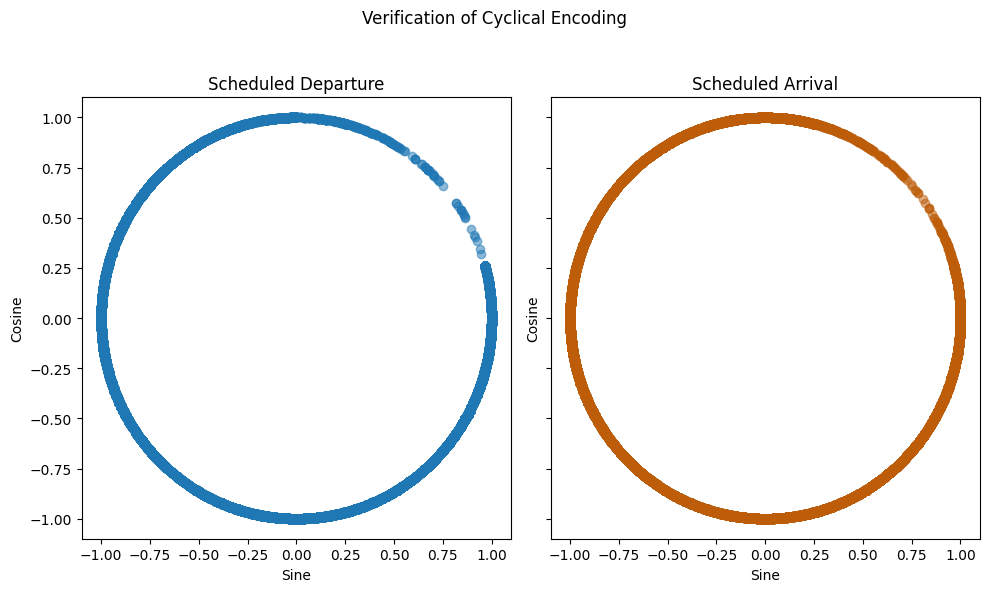

In [21]:
sample_df = df.sample(100000)

departure_color = '#1f77b4'
arrival_color = "#bd5d09"

fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharex=True, sharey=True)
axes[0].scatter(sample_df['scheduledDeparture_sin'], sample_df['scheduledDeparture_cos'], alpha=0.5, color=departure_color)
axes[0].set_title("Scheduled Departure")
axes[0].set_xlabel("Sine")
axes[0].set_ylabel("Cosine")

axes[1].scatter(sample_df['scheduledArrival_sin'], sample_df['scheduledArrival_cos'], alpha=0.5, color=arrival_color)
axes[1].set_title("Scheduled Arrival")
axes[1].set_xlabel("Sine")
axes[1].set_ylabel("Cosine")

fig.suptitle("Verification of Cyclical Encoding")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Sanity check #2

In [22]:
# checking for negative values in CRSElapsedTime
df = df[df['CRSElapsedTime'] >= 0]

Removed rows where scheduled air time is negative. 

### Identify Time zone changes

In [23]:
def compute_timezone_shift(dep_min, arr_min, elapsed):
    # observed elapsed time (handles midnight)
    observed = (arr_min - dep_min) % 1440
    
    # raw timezone offset in minutes
    tz_offset = observed - elapsed
    
    # snap to nearest full hour (in minutes)
    tz_shift = (tz_offset / 60).round() * 60
    
    return tz_shift.astype("Int16")

In [24]:
df["timeZoneShift"] = compute_timezone_shift(
    df["scheduledDepartureTime"],
    df["scheduledArrivalTime"],
    df["CRSElapsedTime"]
)

In [25]:
print(df["timeZoneShift"].value_counts().sort_index().head(30))
df["timeZoneShift"] = pd.to_numeric(df["timeZoneShift"], downcast='integer')

timeZoneShift
-1500           9
-1440          25
-1380           4
-1320           1
-1260           1
-1080           1
-960            1
-720            1
-600            1
-540            1
-420            8
-360         3741
-300         9073
-240        11429
-180       894341
-120      1362373
-60       4577421
0        16342596
60        4626609
120       1358358
180        885447
240         12585
300          9313
360          3694
420            12
960             1
1020            1
1080            1
1200            2
1260            2
Name: count, dtype: Int64


### Unused columns

In [26]:
# ArrDelay is the same as ArrDelayMinutes
df.drop(['ArrDelay'], axis = 1, inplace = True)

# DepDelay is the same as DepDelayMinutes
df.drop(['DepDelay'], axis = 1, inplace = True)

# WheelsOff contins same information as DepTime
df.drop(['WheelsOff'], axis = 1, inplace = True)

# WheelsOn contins same information as ArrTime
df.drop(['WheelsOn'], axis = 1, inplace = True)

# WheelsOff contins same information as DepTime
df.drop(['TaxiOut'], axis = 1, inplace = True)

# WheelsOn contins same information as ArrTime
df.drop(['TaxiIn'], axis = 1, inplace = True)

# AirTime is the same as ActualElapsedTime
df.drop(['AirTime'], axis = 1, inplace = True)

# ActualElapsedTime contains information about the future
df.drop(['ActualElapsedTime'], axis = 1, inplace = True)

# Distance group is unncessary, since we have the actual Distance column
df.drop(['DistanceGroup'], axis = 1, inplace = True)

# After cyclis encoding, the original time columns are no longer needed
df.drop(['scheduledDepartureTime'], axis = 1, inplace = True)
df.drop(['scheduledArrivalTime'], axis = 1, inplace = True)

### Separating Cities from States

In [27]:
# Splitting OriginCityName
df[['OriginCity', 'OriginState']] = df['OriginCityName'].str.split(', ', expand = True)

# Splitting DestCityName
df[['DestCity','DestState']] = df['DestCityName'].str.split(', ', expand = True)

# Dropping the original columns
df.drop(['OriginCityName', 'DestCityName'], axis = 1, inplace = True)

df[['OriginCity', 'OriginState', 'DestCity', 'DestState']]

,OriginCity,OriginState,DestCity,DestState
0,Newark,NJ,Charleston,SC
1,Newark,NJ,Charleston,SC
2,Newark,NJ,Charleston,SC
3,Newark,NJ,Charleston,SC
4,Newark,NJ,Charleston,SC
...,...,...,...,...
30132667,Houston,TX,San Francisco,CA
30132668,Chicago,IL,Philadelphia,PA
30132669,Las Vegas,NV,Chicago,IL
30132670,Miami,FL,Newark,NJ


### Remapping airline names

In [28]:
df.loc[df['Marketing_Airline_Network'] == 'UA', 'CarrierName'] = 'United Airlines'
df.loc[df['Marketing_Airline_Network'] == 'DL', 'CarrierName'] = 'Delta Airlines'
df.loc[df['Marketing_Airline_Network'] == 'F9', 'CarrierName'] = 'Frontier Airlines'
df.loc[df['Marketing_Airline_Network'] == 'NK', 'CarrierName'] = 'Spirit Airlines'
df.loc[df['Marketing_Airline_Network'] == 'AA', 'CarrierName'] = 'American Airlines'
df.loc[df['Marketing_Airline_Network'] == 'WN', 'CarrierName'] = 'Southwest Airlines'
df.loc[df['Marketing_Airline_Network'] == 'AS', 'CarrierName'] = 'Alaska Airlines'
df.loc[df['Marketing_Airline_Network'] == 'HA', 'CarrierName'] = 'Hawaiian Airlines'
df.loc[df['Marketing_Airline_Network'] == 'VX', 'CarrierName'] = 'Virgin America'
df.loc[df['Marketing_Airline_Network'] == 'B6', 'CarrierName'] = 'JetBlue Airways'
df.loc[df['Marketing_Airline_Network'] == 'G4', 'CarrierName'] = 'Allegiant Air'

df['CarrierName'].unique()
df.drop(['Marketing_Airline_Network'], axis = 1, inplace = True)

### Renaming columns to camelCase

In [29]:
df.rename(columns={"DepTime": "departureTime",
                   "DepDelayMinutes": "departureDelay",
                   "TaxiIn": "taxiIn",
                   "TaxiOut": "taxiOut",
                   "ArrTime": "arrivalTime",
                   "ArrDelayMinutes": "arrivalDelay",
                   "ActualElapsedTime": "airTime",
                   "Distance": "distance",
                   "CarrierDelay": "carrierDelay",
                   "WeatherDelay": "weatherDelay",
                   "NASDelay": "nasDelay",
                   "SecurityDelay": "securityDelay",
                   "LateAircraftDelay": "lateAircraftDelay",
                   "DayofWeek": "dayOfWeek",
                   "Holidays": "isHoliday",
                   "OriginCity": "originCity",
                   "OriginState": "originState",
                   "DestCity": "destCity",
                   "DestState": "destState",
                   "CarrierName": "carrierName",
                   "CRSDepTime": "scheduledDepartureTime",
                   "CRSArrTime": "scheduledArrivalTime",
                   "CRSElapsedTime": "scheduledAirTime",
                   "Year": "year",
                   "Month": "month",
                   "DayofMonth": "dayOfMonth",
                   "DayofWeek": "dayOfWeek"
                   }, inplace=True)

### Target Variable

Since our goal is to create an imbalanced regresssion model for delay its best to understand the differences between the types of delay present in this dataset. Delays explained:

`departureDelay` → Total departure delay (in minutes)

`arrivalDelay` → Total arrival delay (in minutes)

`carrierDelay` → airline-related issues (crew, maintenance, etc.)

`weatherDelay` → bad weather

`nasDelay` → air traffic control / airport system issues

`securityDelay` → security-related delays

`lateAircraftDelay` → previous flight was late (domino effect)

In this analysis the target variable to base our regression model on is the `arrivalDelay` column. Due to this choice, we need to additionally drop all the aforementioned columns, as they include after-the-fact knowledge about flight delays. This is done in order to prevent data leakage during training.

### Dropping even more columns

In [30]:
df.drop(['departureDelay'], axis = 1, inplace = True)
df.drop(['carrierDelay'], axis = 1, inplace = True)
df.drop(['weatherDelay'], axis = 1, inplace = True)
df.drop(['nasDelay'], axis = 1, inplace = True)
df.drop(['securityDelay'], axis = 1, inplace = True)
df.drop(['lateAircraftDelay'], axis = 1, inplace = True)

### Dealing with categoricals

In [31]:
categorical_cols = ['originCity', 'originState', 'destCity', 'destState', 'carrierName']

print("Categorical features memory usage:\n")
print(f"Before conversion: {df[categorical_cols].memory_usage(deep=True).sum() / 1024**2:.2f} MB")

for col in categorical_cols:
    df[col] = df[col].astype('category')

print(f"After conversion: {df[categorical_cols].memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Categorical features memory usage:

Before conversion: 8364.44 MB
After conversion: 431.12 MB


### Predictors
`scheduledDepartureTime`, `scheduledArrivalTime`, `scheduledAirTime`, `year`, `month`, `dayOfMonth`, `distance`, `dayOfWeek`, `isHoliday`, `originCity`, `originState`, `destinationCity`, `destinationState`, `carrierName`

### Column state after initial processing

In [32]:
describe_columns(df)

,column,dtype,unique_values
0,year,int16,6
1,month,int8,12
2,dayOfMonth,int8,31
3,arrivalDelay,float32,1974
4,scheduledAirTime,float32,698
5,distance,float32,1752
6,dayOfWeek,int32,7
7,isHoliday,bool,2
8,scheduledDeparture_sin,float64,1271
9,scheduledDeparture_cos,float64,1293


# THIS IS FOR APPLICATION ONLY DO NOT RUN BEFORE IMBALANCED PREPROCESSING

In [ ]:
# df.to_parquet("./Dataset/Flight_Delay_Cleaned.parquet", index=False)

In [ ]:
#df = pd.read_parquet("./Dataset/Flight_Delay_Cleaned.parquet")

In [ ]:
import pandas as pd
import json

def generate_route_topology(df, output_json_path):
    # Rozszerzenie przestrzeni wczytywanych wektorów
    cols = ['originCity', 'originState', 'destCity', 'destState', 'distance', 'scheduledAirTime', 'timeZoneShift']
    df = df[cols]
    
    cities_origin = df[['originCity', 'originState']].rename(columns={'originCity': 'city', 'originState': 'state'})
    cities_dest = df[['destCity', 'destState']].rename(columns={'destCity': 'city', 'destState': 'state'})
    city_to_state = pd.concat([cities_origin, cities_dest]).drop_duplicates().set_index('city')['state'].to_dict()
    
    # Agregacja zmiennych zależnych z wykorzystaniem stałych geograficznych
    route_group = df.groupby(['originCity', 'destCity']).agg({
        'distance': 'first',
        'scheduledAirTime': 'median',
        'timeZoneShift': 'first' # Zmienna deterministyczna dla podanej pary miast
    }).reset_index()
    
    routes = {}
    for _, row in route_group.iterrows():
        orig = row['originCity']
        dest = row['destCity']
        if orig not in routes:
            routes[orig] = {}
        
        # Ekstrakcja zmiennych z wbudowaną rzutowaniem typów i kontrolą wartości NaN
        routes[orig][dest] = {
            'distance': float(row['distance']),
            'air_time': float(row['scheduledAirTime']),
            'tz_shift': float(row['timeZoneShift']) if pd.notna(row['timeZoneShift']) else 0.0
        }
        
    topology_data = {
        'cities': sorted(list(city_to_state.keys())),
        'city_to_state': city_to_state,
        'routes': routes
    }
    
    with open(output_json_path, 'w') as f:
        json.dump(topology_data, f)
        
# Uruchomienie ekstrakcji
#generate_route_topology(df, "route_topology.json")

C:\Users\janas\AppData\Local\Temp\ipykernel_10488\2212563615.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  route_group = df.groupby(['originCity', 'destCity']).agg({


# Imbalanced Preprocessing

We chose the rank based, imbalance-aware relevance function, formally:
\begin{align*}
\Phi{x_i} & = \frac{rank\left(x_i\right)}{N}\\
\end{align*}
This way, the model will focus on relative importance instead of absolute units and retain the significance of the tail-end.

## Modelling Pipeline - Flight Arrival Delay (Imbalanced Regression)
**Models:** Linear Regression · SVR · Random Forest · LightGBM (benchmark)  
**Resampling strategies:** Baseline · RU · RO · Gaussian Noise · SMOTER · WERCS  
**Evaluation:** φ-Precision · φ-Recall · F₁φ (utility-based) + overall RMSE / MAE

### Imports & Feature Preparation

In [41]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split

TARGET = 'arrivalDelay'

df_model = df.dropna(subset=[TARGET]).copy()

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

# Ordinal-encode categoricals
cat_cols = X.select_dtypes(include='category').columns.tolist()
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols] = enc.fit_transform(X[cat_cols])

print(f'Features: {X.shape[1]} | Samples: {len(X):,}')

Features: 17 | Samples: 30,132,602


### Train / Test Split
Split **before** any resampling to prevent data leakage.

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (24106081, 17) | Test: (6026521, 17)


### Relevance Function
Rank-based $\Phi(y)$ computed on **training data only**.  
Threshold $t_R = 0.80$ marks the top 20% of delays as rare/important.

In [43]:
phi_train = y_train.rank(pct=True)
T_R = 0.80

# phi for test set (used in utility metrics)
phi_test = y_test.rank(pct=True)

print(f'Rare samples in train (phi >= {T_R}): {(phi_train >= T_R).sum():,} '
      f'({(phi_train >= T_R).mean()*100:.1f}%)')

Rare samples in train (phi >= 0.8): 4,828,162 (20.0%)


### Resampling - Baseline

### Balancing algorithims

## Vectorised Resampling Functions
Drop-in replacements for the original row-by-row implementations.  
Same API, same results - substantially faster on large datasets.

### `create_bins` - vectorised

In [44]:
def create_bins(X, y, phi, t_r):
    """
    Vectorised bin creation. Returns (bins_N, bins_R) as before.
    Avoids row-by-row Python loop by using sort + cumsum group detection.
    """
    # Sort everything by y
    order      = y.argsort()
    y_s        = y.iloc[order].reset_index(drop=True)
    X_s        = X.iloc[order].reset_index(drop=True)
    phi_s      = phi.iloc[order].reset_index(drop=True)

    # Label each row R or N
    is_R       = (phi_s >= t_r).astype(int)  # 1 = rare, 0 = normal

    # Detect group boundaries where label changes
    group_id   = (is_R.diff().ne(0)).cumsum()

    bins_N, bins_R = [], []
    for gid, grp_idx in X_s.groupby(group_id).groups.items():
        X_grp   = X_s.iloc[grp_idx]
        y_grp   = y_s.iloc[grp_idx]
        if is_R.iloc[grp_idx[0]] == 1:
            bins_R.append((X_grp.reset_index(drop=True),
                           y_grp.reset_index(drop=True)))
        else:
            bins_N.append((X_grp.reset_index(drop=True),
                           y_grp.reset_index(drop=True)))

    return bins_N, bins_R

### `random_under_sampling` - vectorised

In [45]:
def random_under_sampling(bins_N, bins_R, u_percent=0.5):
    """
    Vectorised RU. Uses numpy fancy indexing instead of Python loops.
    """
    X_parts, y_parts = [], []

    # Keep all rare bins
    for bx, by in bins_R:
        X_parts.append(bx)
        y_parts.append(by)

    # Undersample normal bins
    for bx, by in bins_N:
        n = max(1, int(len(bx) * u_percent))
        idx = np.random.choice(len(bx), n, replace=False)
        X_parts.append(bx.iloc[idx])
        y_parts.append(by.iloc[idx])

    return (
        pd.concat(X_parts, ignore_index=True),
        pd.concat(y_parts, ignore_index=True)
    )

### `random_over_sampling` - vectorised

In [46]:
def random_over_sampling(bins_N, bins_R, o_percent=2.0):
    """
    Vectorised RO. Duplicates entire rare bins in one numpy call.
    """
    X_parts, y_parts = [], []

    # Keep all normal bins
    for bx, by in bins_N:
        X_parts.append(bx)
        y_parts.append(by)

    # Oversample rare bins
    for bx, by in bins_R:
        X_parts.append(bx)
        y_parts.append(by)
        n = int(len(bx) * o_percent)
        if n > 0:
            idx = np.random.choice(len(bx), n, replace=True)
            X_parts.append(bx.iloc[idx])
            y_parts.append(by.iloc[idx])

    return (
        pd.concat(X_parts, ignore_index=True),
        pd.concat(y_parts, ignore_index=True)
    )

### `intro_gaussian_noise` - vectorised
Key speedup: generate all synthetic samples as a matrix at once using `np.random.normal`,  
instead of a nested Python loop over rows × replicas.

In [47]:
def intro_gaussian_noise(bins_N, bins_R, u_percent=0.5, o_percent=2.0, delta=0.1):
    """
    Vectorised Gaussian Noise oversampling.
    Numeric perturbation applied as a full matrix operation.
    Categorical columns sampled via vectorised np.random.choice per column.
    """
    X_parts, y_parts = [], []

    # RU for normal bins
    for bx, by in bins_N:
        n = max(1, int(len(bx) * u_percent))
        idx = np.random.choice(len(bx), n, replace=False)
        X_parts.append(bx.iloc[idx])
        y_parts.append(by.iloc[idx])

    # GN for rare bins
    for bx, by in bins_R:
        X_parts.append(bx)
        y_parts.append(by)

        n_orig    = len(bx)
        n_synth   = int(n_orig * o_percent)
        if n_synth == 0:
            continue

        num_cols  = bx.select_dtypes(include=[np.number]).columns
        cat_cols  = bx.select_dtypes(exclude=[np.number]).columns

        # Sample base rows (with replacement)
        base_idx  = np.random.choice(n_orig, n_synth, replace=True)
        synth_X   = bx.iloc[base_idx].copy().reset_index(drop=True)

        # Numeric: add Gaussian noise as a full matrix
        # Numeric: add Gaussian noise as a full matrix
        if len(num_cols) > 0:
            # 1. Pull the standard deviations as a plain numpy array
            stds = bx[num_cols].std().fillna(0).to_numpy(dtype=np.float32)
            
            # 2. Generate the raw 2D noise matrix safely
            noise = np.random.normal(0, delta, size=(n_synth, len(num_cols))) * stds
            
            # 3. Extract base values as a raw numpy float matrix, add noise, and assign back
            # This completely bypasses the pandas extension array ufunc restrictions
            synth_X[num_cols] = synth_X[num_cols].to_numpy(dtype=np.float32) + noise

        # Categorical: vectorised per-column random choice weighted by frequency
        for col in cat_cols:
            vc   = bx[col].value_counts(normalize=True)
            synth_X[col] = np.random.choice(vc.index, size=n_synth, p=vc.values)

        # Target: add noise to base y values
        std_y   = by.std() if not pd.isna(by.std()) else 0
        synth_y = by.iloc[base_idx].values + np.random.normal(0, delta * std_y, n_synth)

        X_parts.append(synth_X)
        y_parts.append(pd.Series(synth_y, name=by.name))

    return (
        pd.concat(X_parts, ignore_index=True),
        pd.concat(y_parts, ignore_index=True)
    )

### `smoter` - vectorised
Key speedup: replace the inner Python loop with a single vectorised interpolation.  
All synthetic points generated as a matrix: `base + w * (neighbor - base)`.

In [ ]:
from sklearn.neighbors import NearestNeighbors

def smoter(bins_N, bins_R, k_neighbors=5, o_percent=2.0):
    """
    Vectorised SMOTER. Interpolation computed as a full matrix operation
    instead of row-by-row Python loop.
    """
    X_parts, y_parts = [], []

    for bx, by in bins_N:
        X_parts.append(bx)
        y_parts.append(by)

    for bx, by in bins_R:
        X_parts.append(bx)
        y_parts.append(by)

        n_orig  = len(bx)
        n_synth = int(n_orig * o_percent)
        if n_orig < 2 or n_synth == 0:
            continue

        num_cols = bx.select_dtypes(include=[np.number]).columns
        bx_num   = bx[num_cols].values  # (n_orig, n_features)

        actual_k = min(k_neighbors, n_orig - 1)
        # n_jobs=-1 uses all CPU cores. algorithm='kd_tree' prevents brute-force fallback.
        nn = NearestNeighbors(n_neighbors=actual_k, n_jobs=-1, algorithm='kd_tree').fit(bx_num)

        # Sample base indices and find their neighbours - all at once
        base_idx     = np.random.randint(0, n_orig, n_synth)          # (n_synth,)
        all_neighbors = nn.kneighbors(bx_num[base_idx],               # (n_synth, k)
                                      return_distance=False)
        # Pick one neighbour per synthetic sample
        pick         = np.random.randint(0, actual_k, n_synth)
        neighbor_idx = all_neighbors[np.arange(n_synth), pick]        # (n_synth,)

        # Interpolation weights
        w            = np.random.random(n_synth)[:, None]              # (n_synth, 1)

        # Numeric interpolation as matrix op
        base_num     = bx_num[base_idx]                                # (n_synth, n_features)
        neighbor_num = bx_num[neighbor_idx]                            # (n_synth, n_features)
        synth_num    = base_num + w * (neighbor_num - base_num)        # (n_synth, n_features)

        # Rebuild full dataframe (categoricals inherited from base)
        synth_X              = bx.iloc[base_idx].copy().reset_index(drop=True)
        synth_X[num_cols]    = synth_num

        # Target interpolation
        by_arr    = by.values
        synth_y   = by_arr[base_idx] + w.squeeze() * (by_arr[neighbor_idx] - by_arr[base_idx])

        X_parts.append(synth_X)
        y_parts.append(pd.Series(synth_y, name=by.name))

    return (
        pd.concat(X_parts, ignore_index=True),
        pd.concat(y_parts, ignore_index=True)
    )

### `wercs` - vectorised
Already mostly vectorised in the original. Minor cleanup only.

In [ ]:
def wercs(X, y, phi, u_percent=0.5, o_percent=0.5):
    """
    Vectorised WERCS. Weights normalised and applied via np.random.choice.
    """
    idx = X.index

    # Oversample - weights proportional to phi
    w_ove    = phi / phi.sum()
    n_ove    = int(len(X) * o_percent)
    ove_idx  = np.random.choice(idx, size=n_ove, replace=True, p=w_ove)

    # Undersample - remove samples with weight proportional to (1 - phi)
    w_und    = (1 - phi) / (1 - phi).sum()
    n_und    = int(len(X) * u_percent)
    # Clip n_und so we don't try to remove more rows than exist
    n_und    = min(n_und, len(X) - 1)
    rem_idx  = np.random.choice(idx, size=n_und, replace=False, p=w_und)

    keep_mask = ~pd.Index(idx).isin(rem_idx)
    X_und     = X.loc[keep_mask]
    y_und     = y.loc[keep_mask]

    return (
        pd.concat([X_und, X.loc[ove_idx]], ignore_index=True),
        pd.concat([y_und, y.loc[ove_idx]], ignore_index=True)
    )

In [50]:
X_base, y_base = X_train.copy(), y_train.copy()
print(f'Baseline: {len(X_base):,} rows')

Baseline: 24,106,081 rows


### Resampling - Random Under / Over Sampling

In [51]:
bins_N, bins_R = create_bins(X_train, y_train, phi_train, T_R)

X_ru, y_ru = random_under_sampling(bins_N, bins_R, u_percent=0.5)
X_ro, y_ro = random_over_sampling(bins_N, bins_R, o_percent=1.5)

print(f'RU: {len(X_ru):,} rows')
print(f'RO: {len(X_ro):,} rows')

RU: 14,467,121 rows
RO: 31,348,324 rows


### Resampling - Gaussian Noise

In [52]:
X_gn, y_gn = intro_gaussian_noise(bins_N, bins_R,
                                   u_percent=0.5, o_percent=2.0, delta=0.1)
print(f'GaussNoise: {len(X_gn):,} rows')

GaussNoise: 24,123,445 rows


### Resampling - SMOTER

In [53]:
X_sm, y_sm = smoter(bins_N, bins_R, k_neighbors=5, o_percent=1.5)
print(f'SMOTER: {len(X_sm):,} rows')

SMOTER: 31,348,324 rows


### Resampling - WERCS

In [54]:
X_we, y_we = wercs(X_train, y_train, phi_train, u_percent=0.3, o_percent=0.5)
print(f'WERCS: {len(X_we):,} rows')

WERCS: 28,927,297 rows


### Resampling Summary

In [55]:
datasets = {
    'Baseline':   (X_base, y_base),
    'RU':         (X_ru,   y_ru),
    'RO':         (X_ro,   y_ro),
    'GaussNoise': (X_gn,   y_gn),
    'SMOTER':     (X_sm,   y_sm),
    'WERCS':      (X_we,   y_we),
}

summary = pd.DataFrame(
    {'rows': {name: len(Xr) for name, (Xr, _) in datasets.items()}}
)
summary['vs_baseline'] = (summary['rows'] / len(X_base)).round(2)
summary

,rows,vs_baseline
Baseline,24106081,1.0
RU,14467121,0.6
RO,31348324,1.3
GaussNoise,24123445,1.0
SMOTER,31348324,1.3
WERCS,28927297,1.2


In [ ]:
import joblib

pipeline_inputs = {
    'datasets': datasets,
    'X_test': X_test,
    'y_test': y_test,
    'phi_test': phi_test,
}

print("Saving heavy datasets to disk...")
joblib.dump(pipeline_inputs, 'pipeline_inputs.joblib')
print("Successfully saved to 'pipeline_inputs.joblib'!")

Saving heavy datasets to disk...
Successfully saved to 'pipeline_inputs.joblib'!
